In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
import pickle

with open("Corr_len_cytnx.pkl", "rb") as file:
    loaded_data = pickle.load(file)
    
Corr_len_cytnx = loaded_data['Corr_len']
Corr_len_2_cytnx = loaded_data['Corr_len_2']
Corr_len_4_cytnx = loaded_data['Corr_len_4']
Corr_len_10_cytnx = loaded_data['Corr_len_10']
Corr_len_20_cytnx = loaded_data['Corr_len_20']

In [3]:
def get_W(beta, J=1, h=0):
    """
    Calculate the matrix W based on beta, J, and h.
    
    Parameters:
        beta (float): Inverse temperature.
        J (float): Interaction strength (default is 1).
        h (float): External field strength (default is 0).

    Returns:
        torch.Tensor: Matrix W.
    """
    sq_cosh = np.sqrt(np.cosh(beta * J))
    sq_sinh = np.sqrt(np.sinh(beta * J))
    W = torch.tensor([
        [sq_cosh, sq_sinh],
        [sq_cosh, -sq_sinh]
    ])
    return W


#可能Wh是正確的包含h的作法
def get_Wh(beta, J, h):
    """
    Calculate the matrix Wh incorporating the external field h.
    
    Parameters:
        beta (float): Inverse temperature.
        J (float): Interaction strength.
        h (float): External field strength.

    Returns:
        torch.Tensor: Matrix Wh.
    """
    cosh = np.cosh(beta * J)
    sinh = np.sinh(beta * J)

    Wh = torch.tensor([
        [np.sqrt(cosh) * np.exp(beta * h / 2), np.sqrt(sinh) * np.exp(beta * h / 2)],
        [np.sqrt(cosh) * np.exp(-beta * h / 2), -np.sqrt(sinh) * np.exp(-beta * h / 2)]
    ])
    return Wh


# 上左右下
def get_T_bare(beta, J=1, h=0, get_W=get_W):
    """
    Calculate the bare transfer matrix T_bare.
    
    Parameters:
        beta (float): Inverse temperature.
        J (float): Interaction strength (default is 1).
        h (float): External field strength (default is 0).
        get_W (callable): Function to calculate W or Wh (default is get_W).

    Returns:
        torch.Tensor: Bare transfer matrix T_bare.
    """
    W = get_W(beta, J=J, h=h)
    T_bare = torch.einsum('ai,aj,ak,al->ijkl', W, W, W, W)
    return T_bare

def merge_y(Tup, Tdn, combine=False, trace=False):
    if trace:
        Tmerge = torch.einsum('abcd,defa->becf', Tup, Tdn)
        
        if combine:
            shape = Tmerge.shape
            Tmerge = Tmerge.contiguous().view(shape[0] * shape[1], shape[2] * shape[3])
    else:
        Tmerge = torch.einsum('abcd,defg->abecfg', Tup, Tdn)
        
        if combine:
            shape = Tmerge.shape
            Tmerge = Tmerge.contiguous().view(shape[0], shape[1] * shape[2], shape[3] * shape[4], shape[5])
            
    return Tmerge


def merge_y_truncate(Tup, Tdn, dcut):
    if ((Tup.shape[1] * Tdn.shape[1]) < dcut):
        return merge_y(Tup, Tdn, True)
    Tmerge_pure = torch.einsum('aAbc,cBef,aCbd,dDef->ABCD', Tup, Tdn, Tup, Tdn)
    Tmerge_pure_shape = Tmerge_pure.shape
    Tmerge_pure = Tmerge_pure.contiguous().view(
        Tmerge_pure_shape[0] * Tmerge_pure_shape[1],Tmerge_pure_shape[2] * Tmerge_pure_shape[3]
    )
    U, S, V = torch.svd(Tmerge_pure)
    U = U[:,:dcut]
    U = U.view(Tmerge_pure_shape[0], Tmerge_pure_shape[1], dcut)
    Tmerge = torch.einsum('Aace,ebdD,cdC,abB->ABCD', Tup, Tdn, U, U)
    return Tmerge

def merge_x(TL, TR, combine=False, trace=False):
    if trace:
        Tmerge = torch.einsum('aAca,ecBe->AB', TL, TR)
    else:
        Tmerge = torch.einsum('BCaF,AaDE->ABCDEF', TL, TR)
        
        if combine:
            shape = Tmerge.shape
            Tmerge = Tmerge.contiguous().view(shape[0] * shape[1], shape[2], shape[3], shape[4] * shape[5])
            
    return Tmerge

def merge_x_truncate(TL, TR, dcut):
    if ((TL.shape[0] * TR.shape[0]) < dcut):
        return merge_x(TL, TR, True)
    Tmerge_pure = torch.einsum('abcd,ecfg,hbid,jifg->aehj', TL, TR, TL, TR)
    Tmerge_pure_shape = Tmerge_pure.shape
    Tmerge_pure = Tmerge_pure.contiguous().view(
        Tmerge_pure_shape[0] * Tmerge_pure_shape[1],Tmerge_pure_shape[2] * Tmerge_pure_shape[3]
    )
    U, S, V = torch.svd(Tmerge_pure)
    U = U[:,:dcut]
    U = U.view(Tmerge_pure_shape[0], Tmerge_pure_shape[1], dcut)
    Tmerge = torch.einsum('abcd,ecfg,aeh,dgi->hbfi', TL, TR, U, U)
    return Tmerge

In [4]:
MaxL = 4
Temp = np.linspace(2.26,4,100)
W = np.ones((MaxL+1,len(Temp),2))
E = np.ones((MaxL+1,len(Temp),2))
M01 = np.ones((MaxL+1,len(Temp)))
Tc = 2/np.log(1+np.sqrt(2))

In [5]:
%%time

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TL_Trace = merge_y(TL,TL,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        del TL_Trace
        if j != MaxL:
            TL = merge_y(TL,TL,True)
E = -np.log(W)
Corr_len = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len, Corr_len_cytnx)

<timed exec>:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.


CPU times: user 23.6 s, sys: 356 ms, total: 24 s
Wall time: 1.56 s


<timed exec>:12: RuntimeWarning: divide by zero encountered in divide


True

In [6]:
%%time
dcut = 2

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_2 = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len_2, Corr_len_2_cytnx)

<timed exec>:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.


CPU times: user 342 ms, sys: 7.58 ms, total: 349 ms
Wall time: 381 ms


<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


True

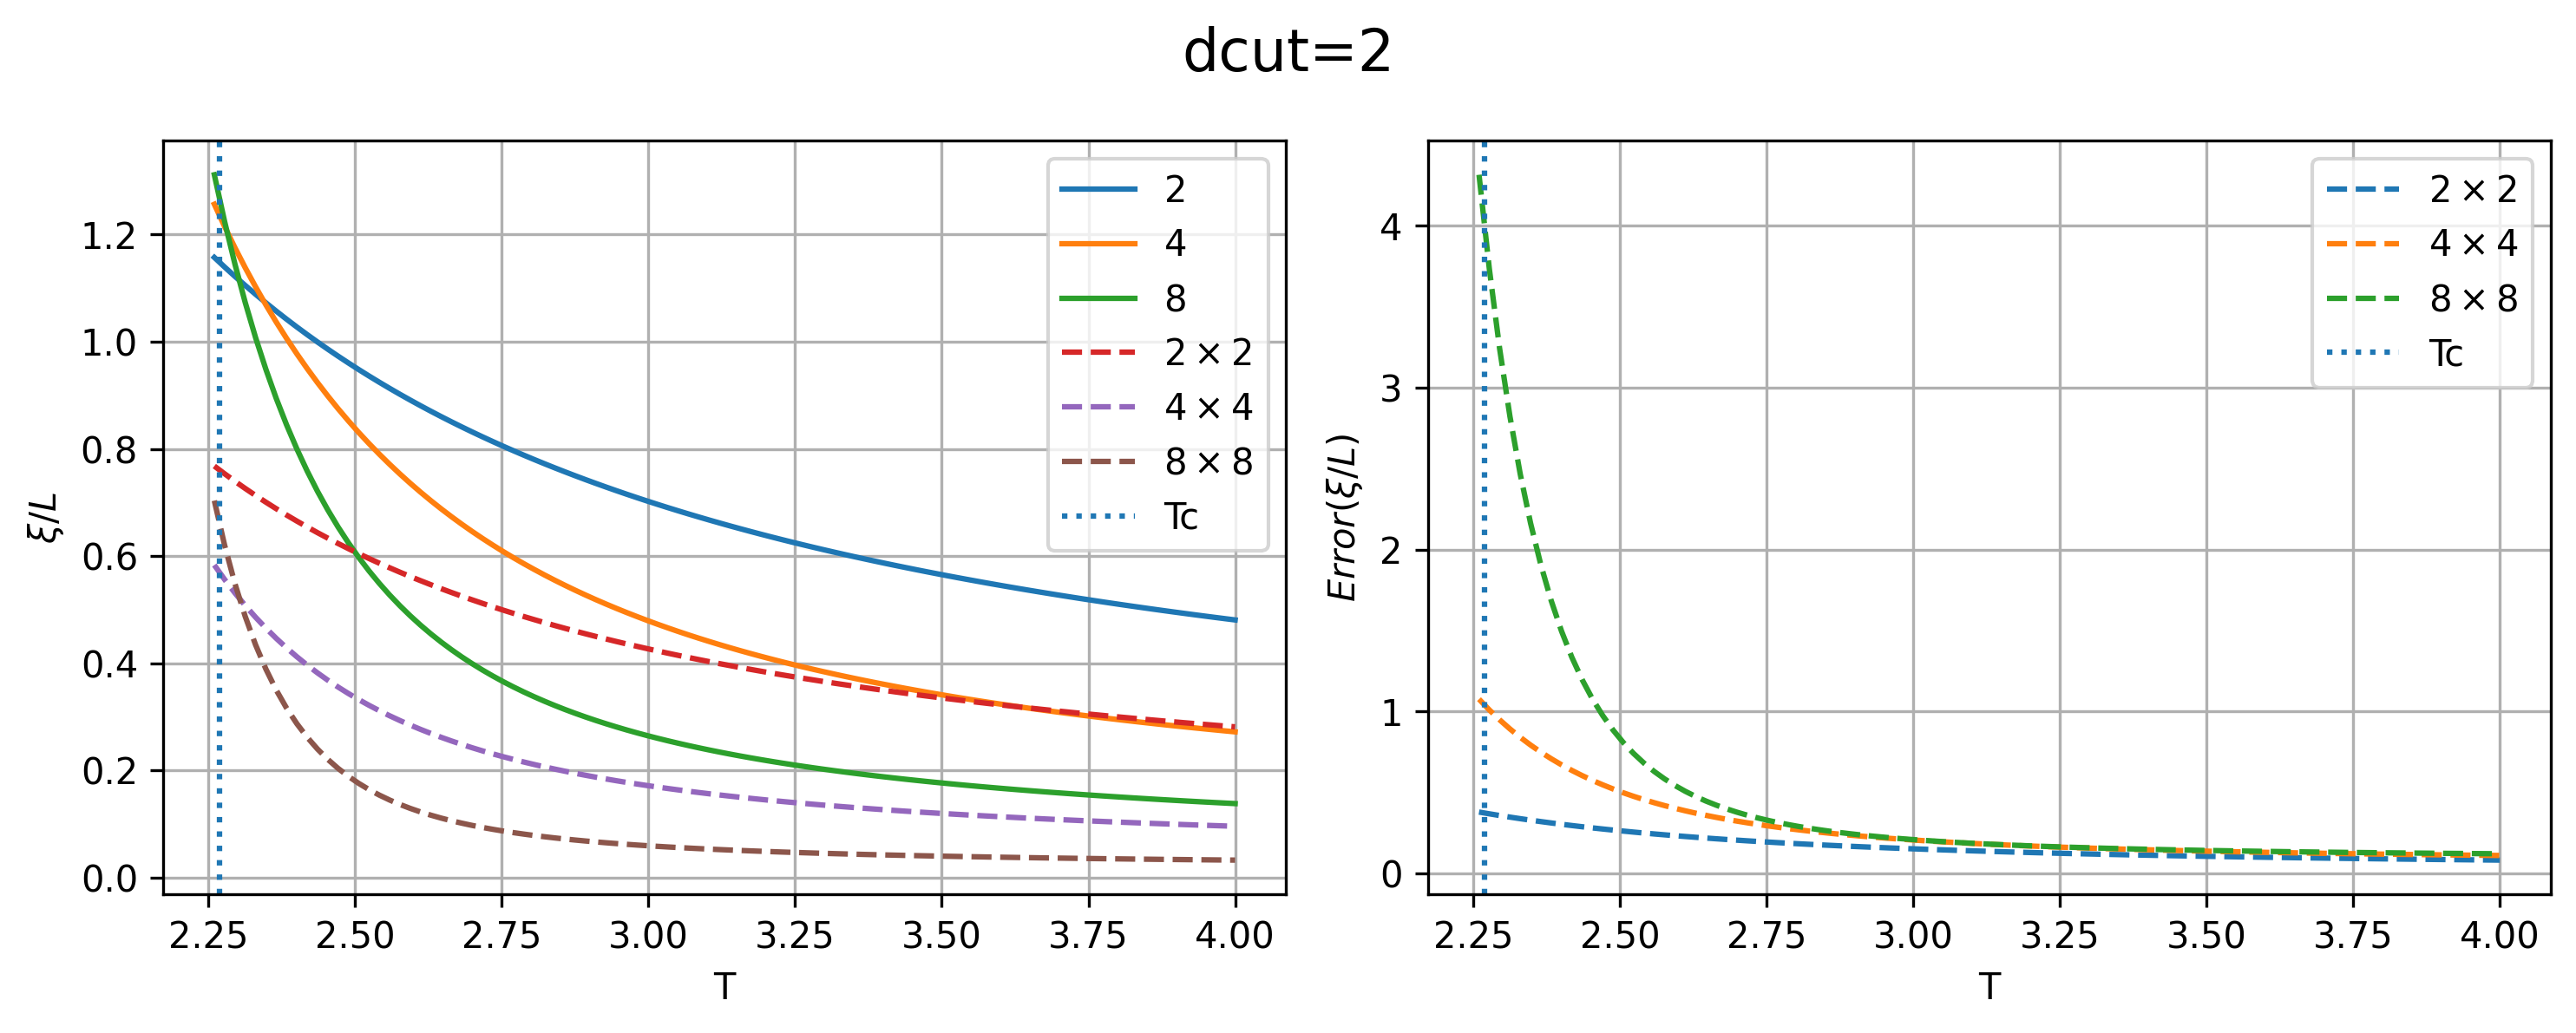

In [7]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_2[i]/2**(i-1),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_2[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
%%time
dcut = 4

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_4 = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len_4, Corr_len_4_cytnx)

<timed exec>:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.


CPU times: user 1.96 s, sys: 8.71 ms, total: 1.97 s
Wall time: 463 ms


<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


True

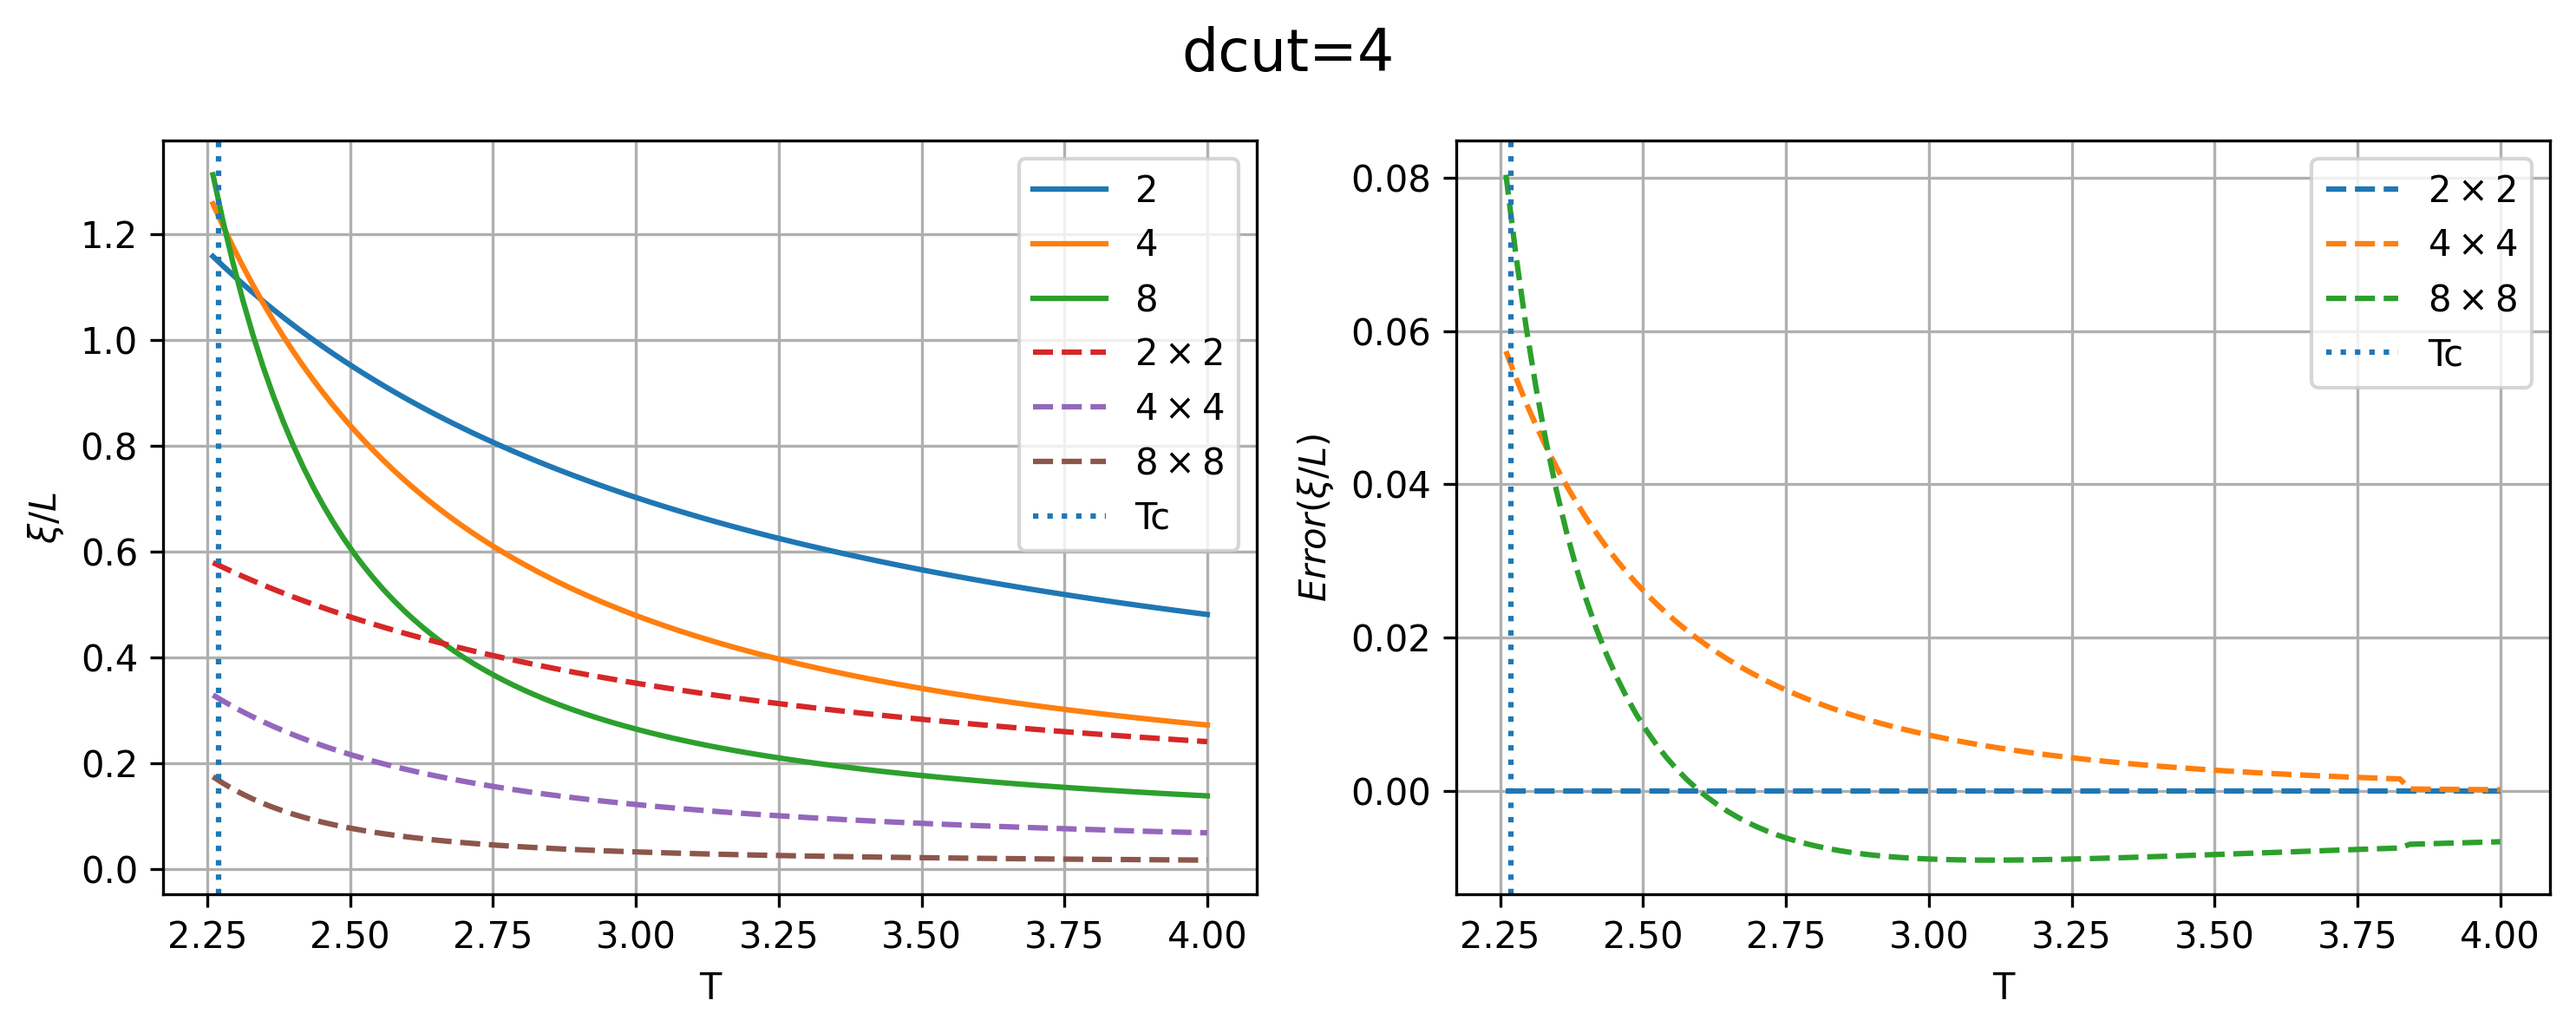

In [9]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_4[i]/2**(i-1),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_4[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
%%time
dcut = 10

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_10 = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len_10, Corr_len_10_cytnx)

<timed exec>:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.


CPU times: user 1min 14s, sys: 5.42 s, total: 1min 19s
Wall time: 2.33 s


<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


True

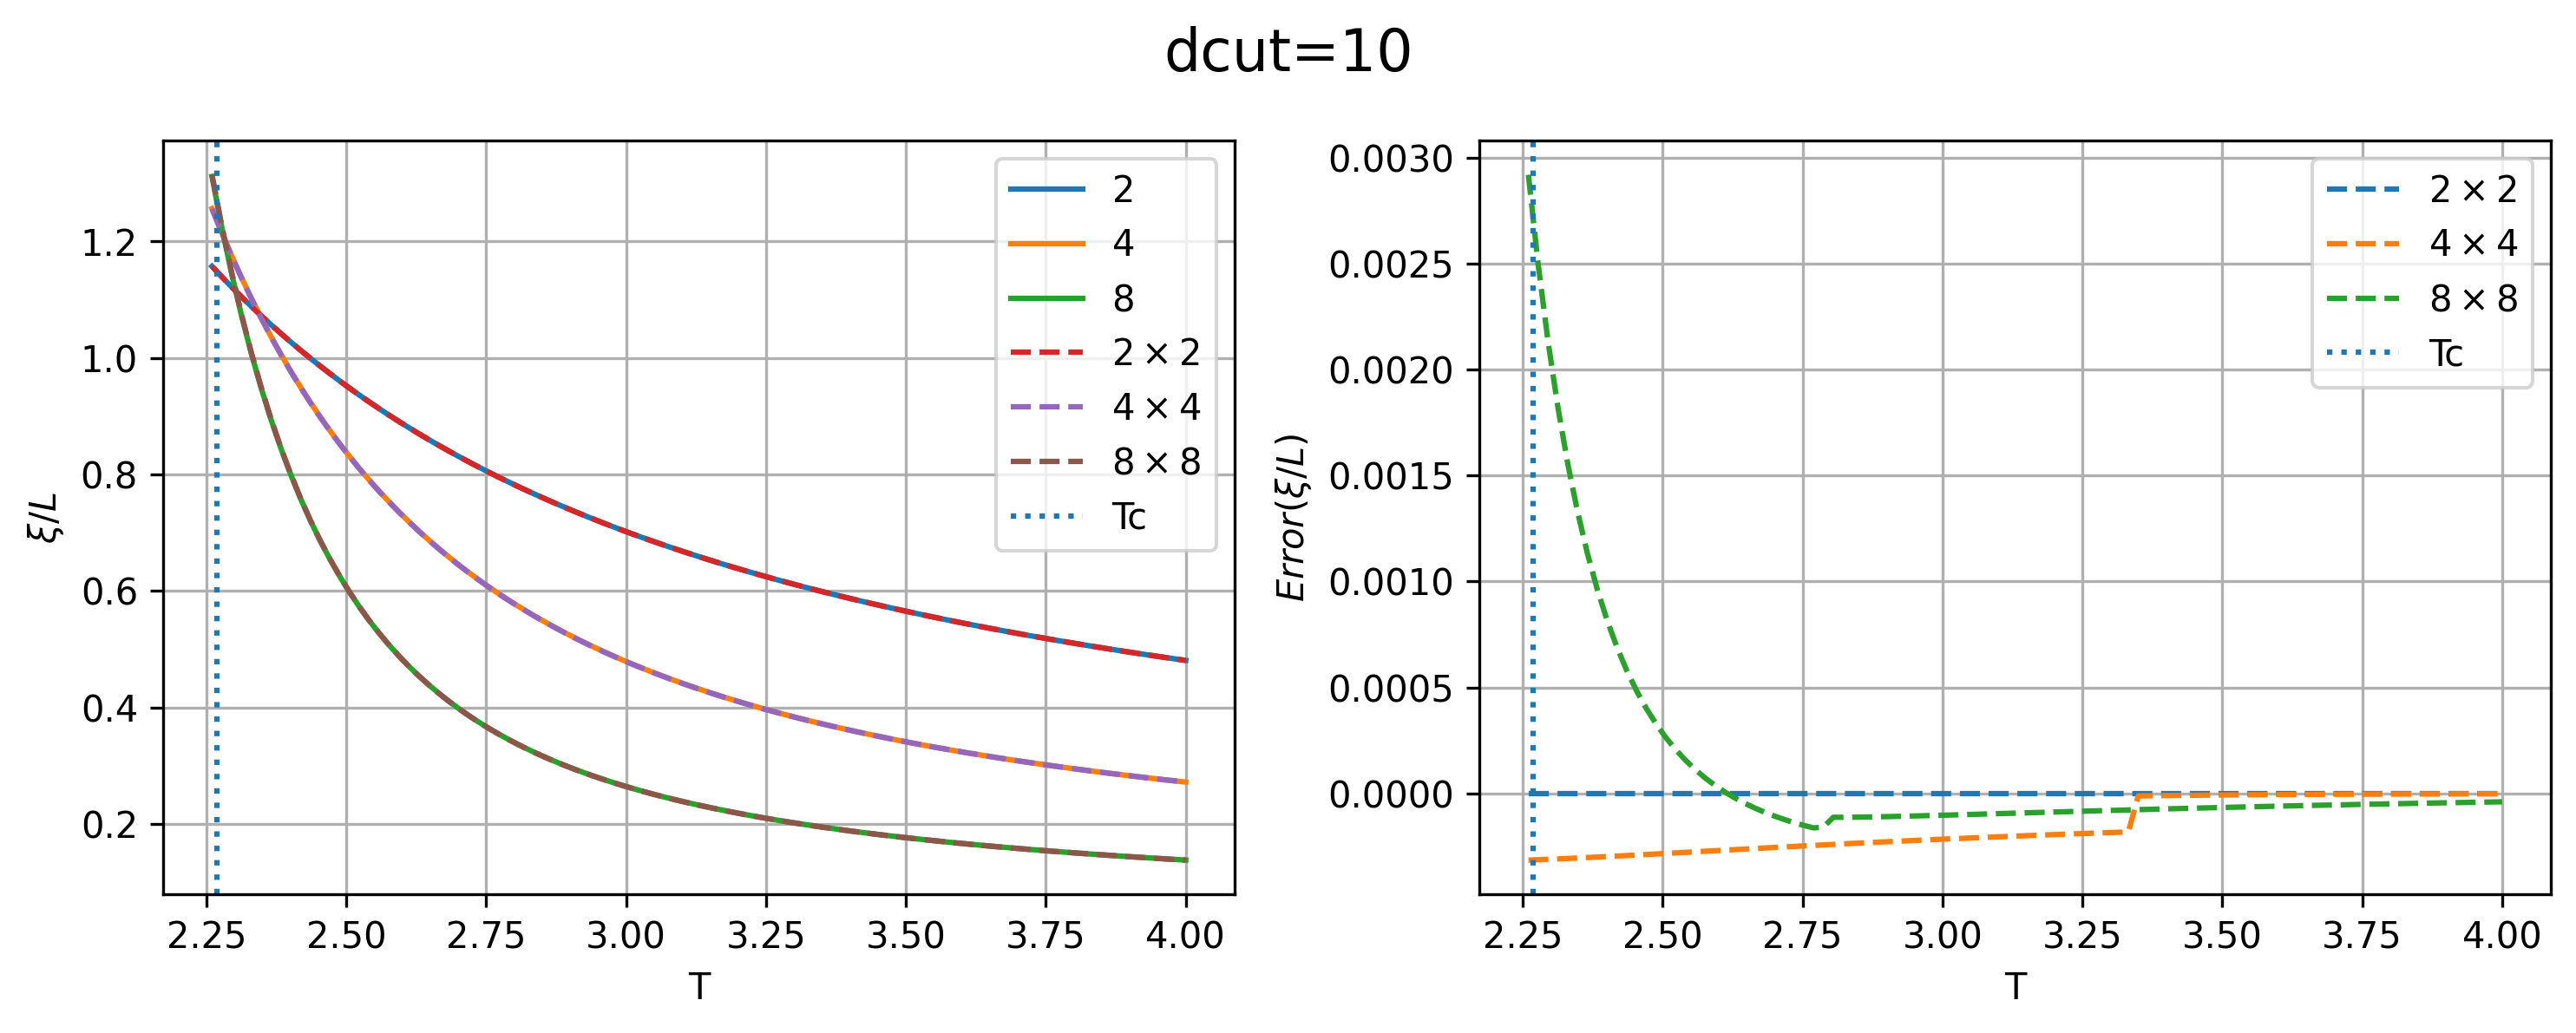

In [11]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_10[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_10[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
%%time
dcut = 20

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_20 = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len_20, Corr_len_20_cytnx)

<timed exec>:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.


CPU times: user 9min 10s, sys: 5min 25s, total: 14min 35s
Wall time: 39.7 s


<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


True

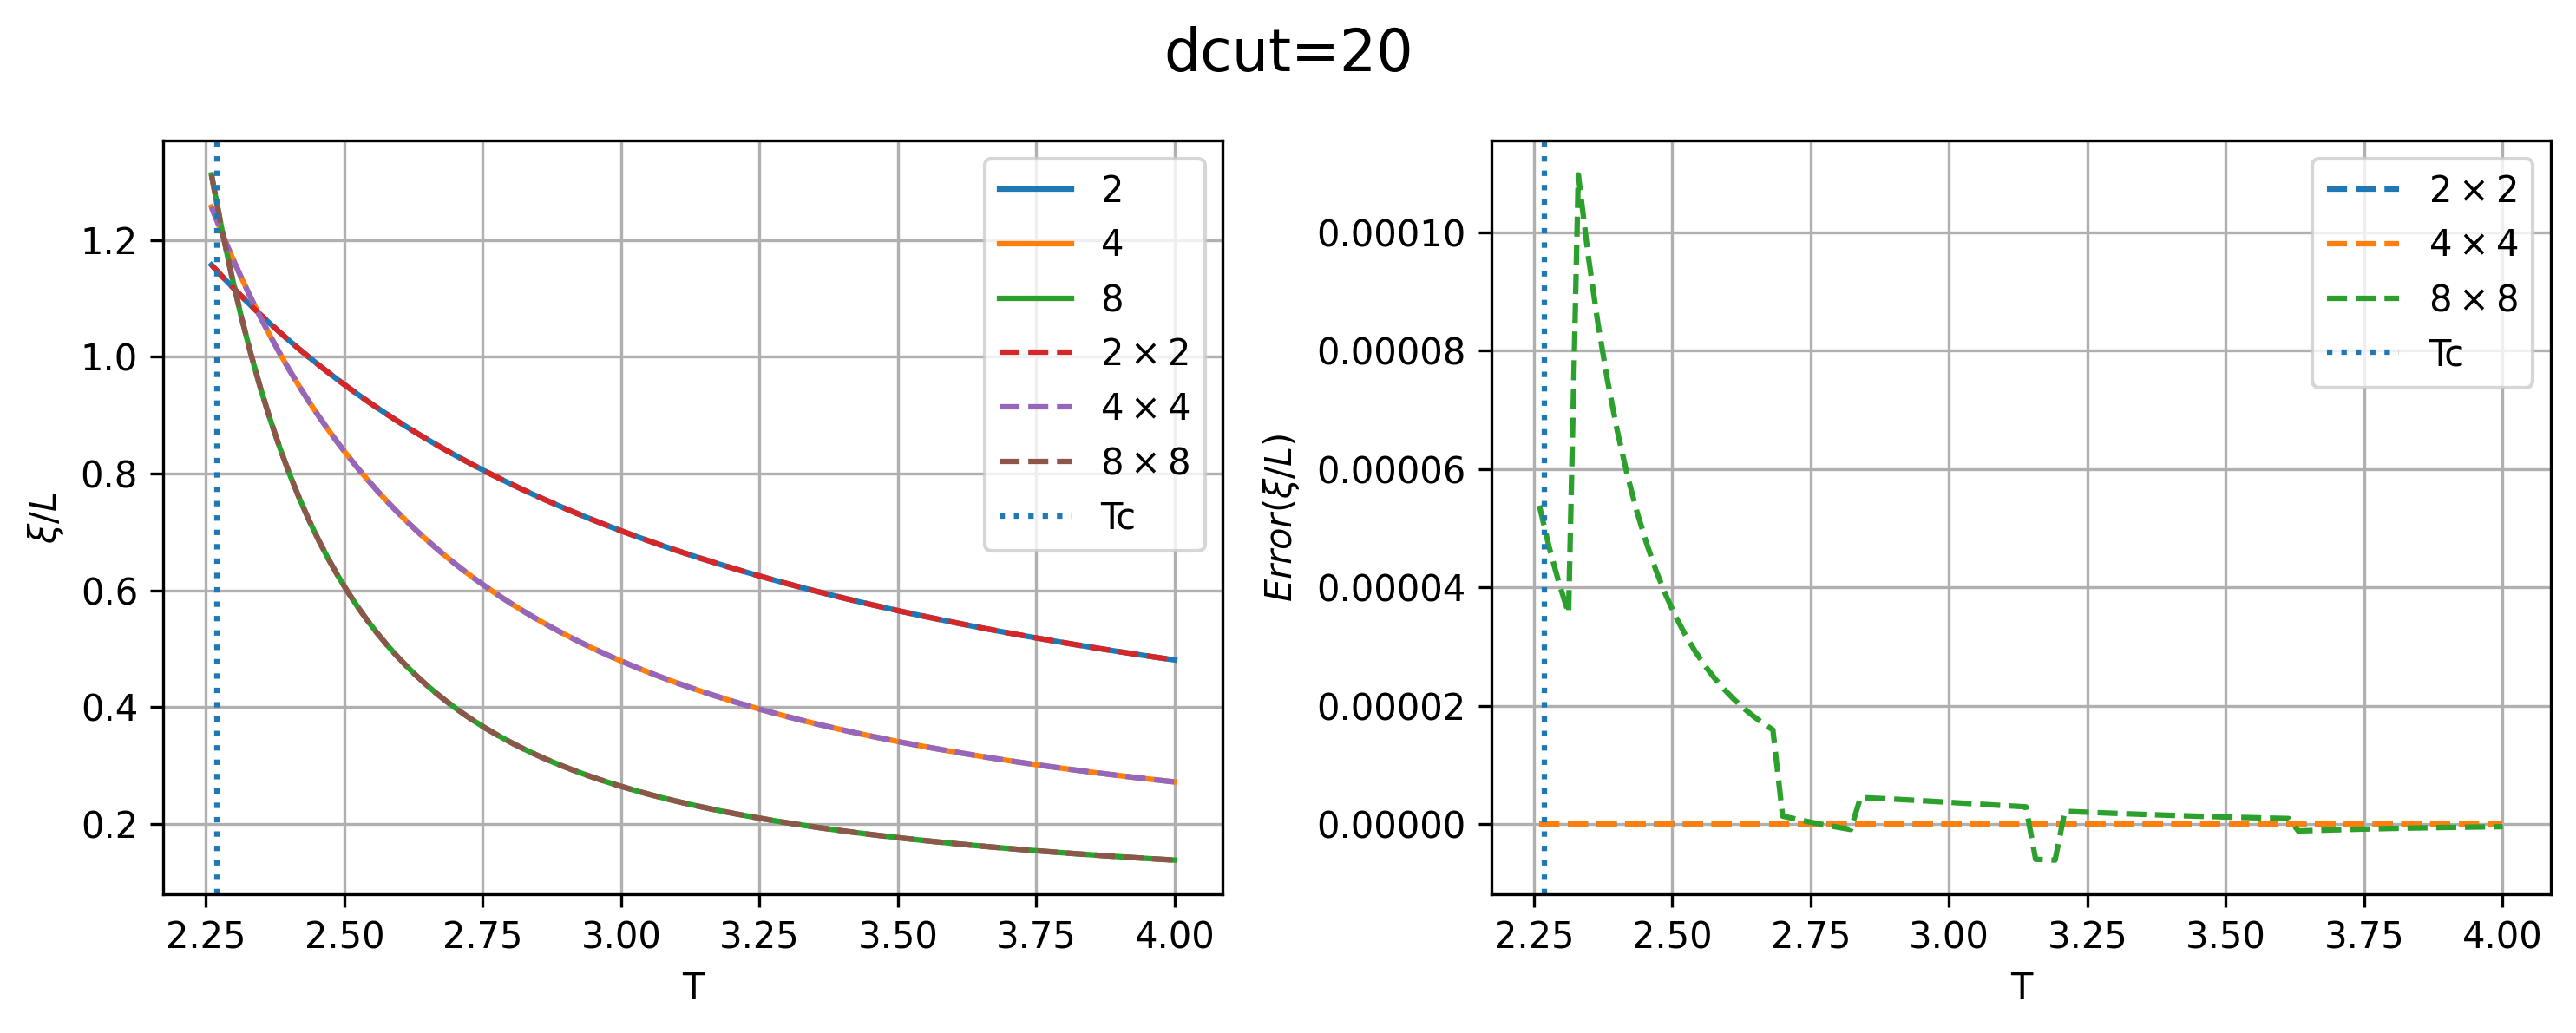

In [13]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_20[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
MaxL = 11
Temp = np.linspace(2.2,2.35,100)
Tc = 2/np.log(1+np.sqrt(2))
dbeta = 1e-3

In [15]:
%%time
dcut = 16

Cv = np.zeros((MaxL+1,len(Temp)))

for i,temp in enumerate(Temp):
    beta = 1/temp
    T_bare = get_T_bare(beta - dbeta)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        Cv[j,i] += torch.log(eigvals[-1])
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
        
    T_bare = get_T_bare(beta)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        Cv[j,i] -= 2 * torch.log(eigvals[-1])
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
        
    T_bare = get_T_bare(beta + dbeta)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        Cv[j,i] += torch.log(eigvals[-1])
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
        
    Cv[:,i] = Cv[:,i] * (beta ** 2) / (dbeta ** 2)

CPU times: user 3h 8min 1s, sys: 1h 44min 12s, total: 4h 52min 13s
Wall time: 12min 46s


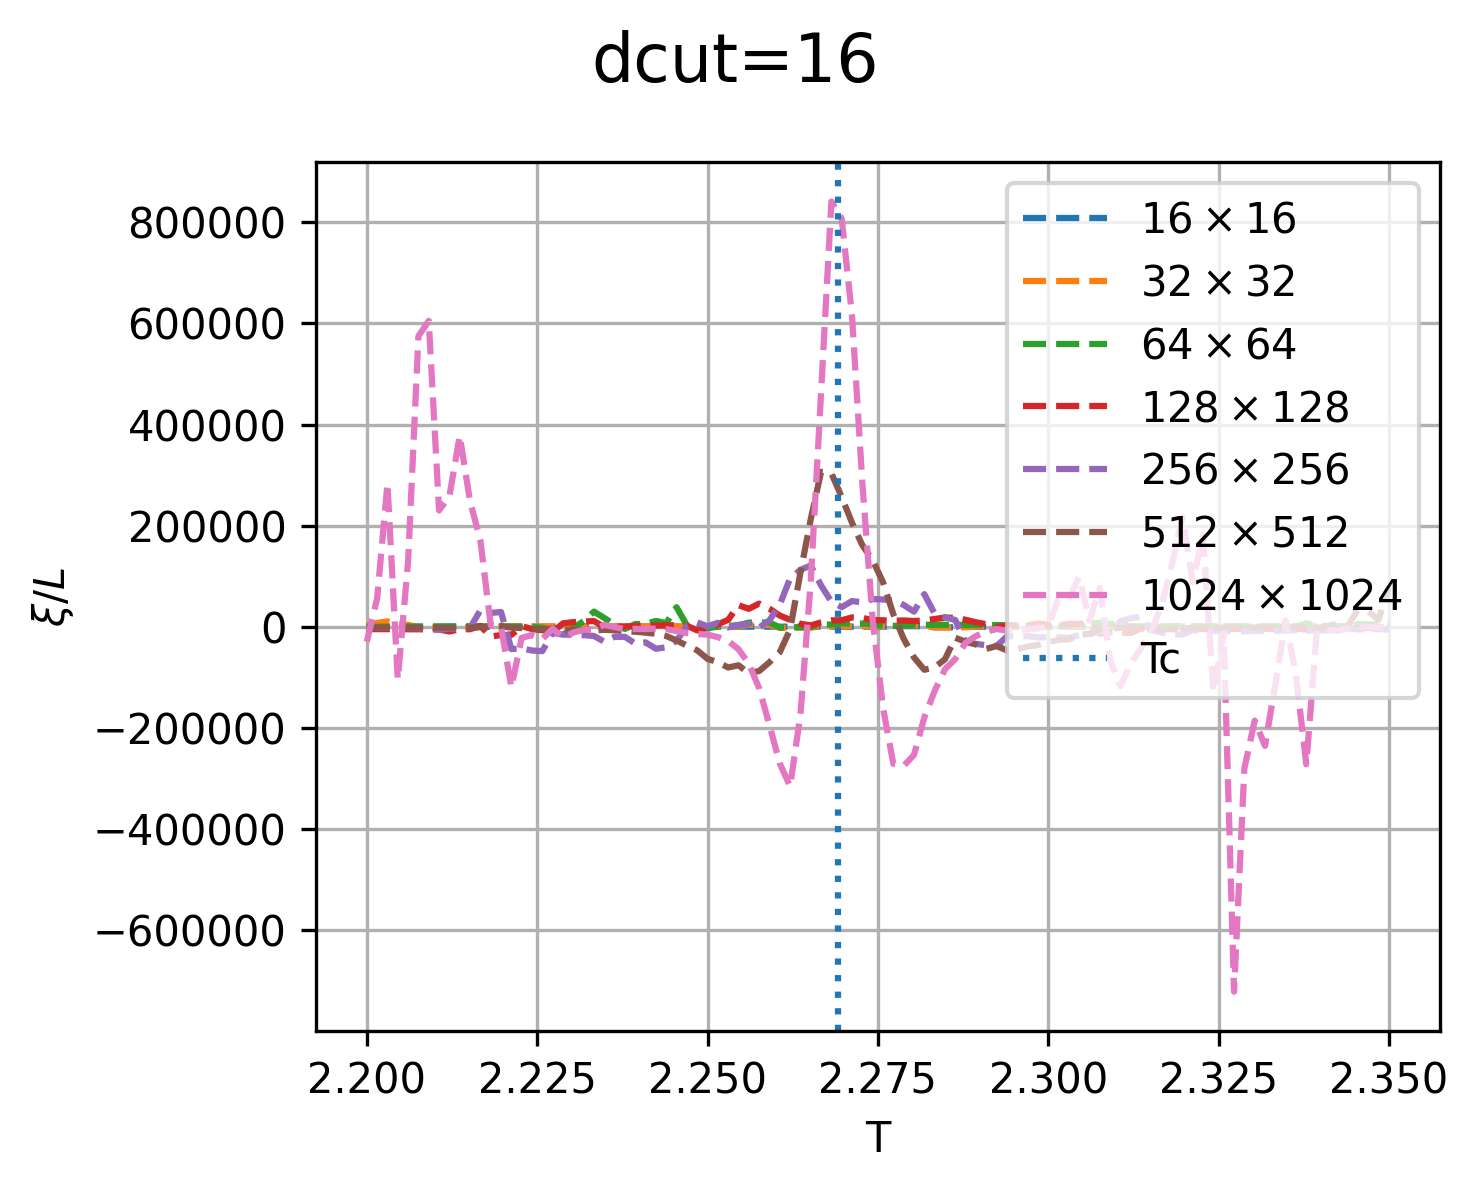

In [16]:
plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(5,MaxL+1):
    plt.plot(Temp,Cv[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
from multiprocessing import Pool


def compute_Cv_for_temp(temp):
    """計算單一溫度下的 Cv"""
    temp = temp
    beta = 1 / temp
    Cv_i = np.zeros(MaxL + 1)

    T_bare = get_T_bare(beta - dbeta)
    TL = T_bare
    for j in range(2, MaxL + 1):
        TLx = merge_x_truncate(TL, TL, dcut)
        TL_Trace = merge_y(TLx, TLx, True, True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        Cv_i[j] += torch.log(eigvals[-1]).item()
        TL = merge_y_truncate(TLx, TLx, dcut)
        TL = TL / torch.mean(torch.abs(TL))

    T_bare = get_T_bare(beta)
    TL = T_bare
    for j in range(2, MaxL + 1):
        TLx = merge_x_truncate(TL, TL, dcut)
        TL_Trace = merge_y(TLx, TLx, True, True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        Cv_i[j] -= 2 * torch.log(eigvals[-1]).item()
        TL = merge_y_truncate(TLx, TLx, dcut)
        TL = TL / torch.mean(torch.abs(TL))

    T_bare = get_T_bare(beta + dbeta)
    TL = T_bare
    for j in range(2, MaxL + 1):
        TLx = merge_x_truncate(TL, TL, dcut)
        TL_Trace = merge_y(TLx, TLx, True, True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        Cv_i[j] += torch.log(eigvals[-1]).item()
        TL = merge_y_truncate(TLx, TLx, dcut)
        TL = TL / torch.mean(torch.abs(TL))

    Cv_i = Cv_i * (beta ** 2) / (dbeta ** 2)
    return i, Cv_i

# 初始化參數
# Temp 是溫度列表
Cv = np.zeros((MaxL + 1, len(Temp)))

def parallel_compute_Cv():
    """使用 multiprocessing 平行化計算 Cv"""
    with Pool(processes=4) as pool:  # 4 個進程，根據 CPU 核心數調整
        results = pool.map(compute_Cv_for_temp, enumerate(Temp))

    # 將結果合併回主矩陣
    for i, Cv_i in results:
        Cv[:, i] = Cv_i

# 計時並執行
if __name__ == "__main__":
    import time
    start_time = time.time()
    parallel_compute_Cv()
    print(f"計算完成，用時 {time.time() - start_time:.2f} 秒")


In [ ]:
from multiprocessing import Pool
import time

def task(x):
    time.sleep(1)
    return x * x

if __name__ == "__main__":
    with Pool(4) as pool:  # 建立 4 個進程的進程池
        results = pool.map(task, range(10))  # 平行執行任務
    print("結果:", results)


In [35]:
%%time
dcut = 40

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TL_Trace = merge_y(TL,TL,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TL,TL,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_20 = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len_20, Corr_len_20_cytnx)

<timed exec>:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.


IndexError: index 5 is out of bounds for axis 0 with size 5

IndexError: index 5 is out of bounds for axis 0 with size 5

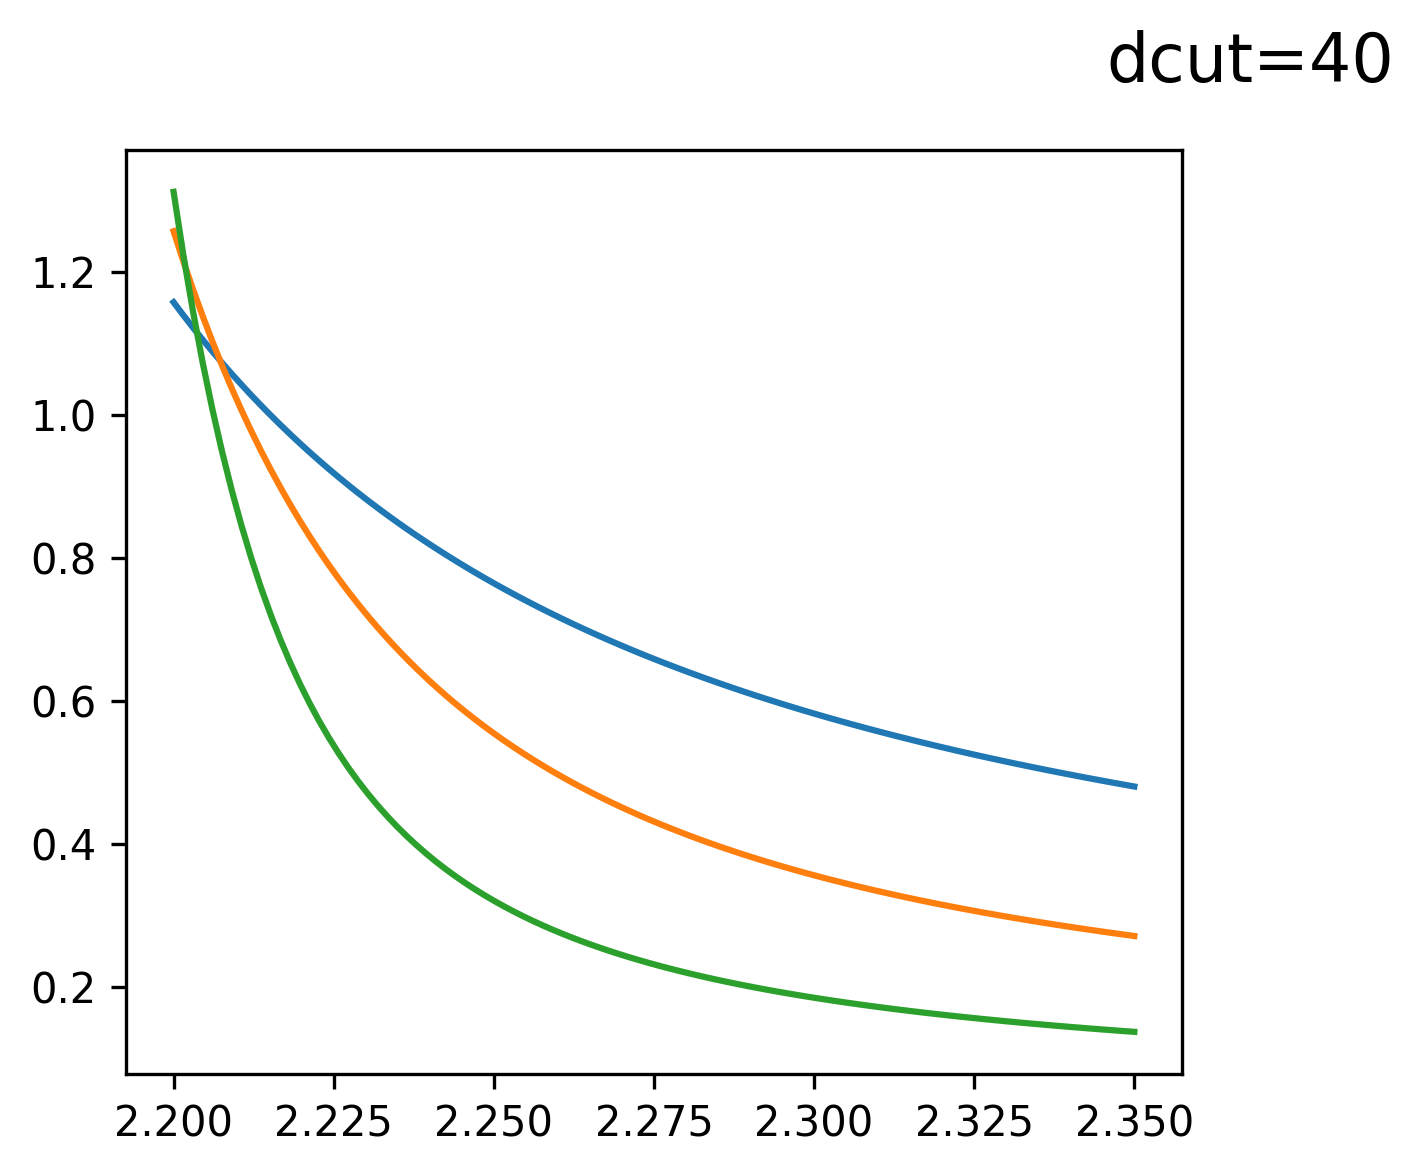

In [36]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i]/2**(i-1),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, (Corr_len_20[i]/2**(i-1)) - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
%%time
dcut = 30

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_40 = 1/(E[:,:,-2]-E[:,:,-1])

In [ ]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_40[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_40[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
MaxL = 11
Temp = np.linspace(2.265,2.285,100)
W = np.ones((MaxL+1,len(Temp),2))
E = np.ones((MaxL+1,len(Temp),2))
Tc = 2/np.log(1+np.sqrt(2))

In [ ]:

dcut = 12

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        del TL_Trace
        W[j,i,:] = np.asarray(eigvals[-2:])
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
    del TL
E = -np.log(W)
Corr_len_20 = 1/(E[:,:,-2]-E[:,:,-1])

plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.ylim((0,15))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i],'-',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.ylim((1.273,1.278))
plt.xlim((Tc-1e-5,Tc+5e-5))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

dcut = 14

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        del TL_Trace
        W[j,i,:] = np.asarray(eigvals[-2:])
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
    del TL
E = -np.log(W)
Corr_len_20 = 1/(E[:,:,-2]-E[:,:,-1])

plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.ylim((0,15))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
%%time
dcut = 40

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TL_Trace = merge_y(TL,TL,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TL,TL,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_20 = 1/(E[:,:,-2]-E[:,:,-1])

plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i]/2**(i-1),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.ylim((0,15))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
%%time
dcut = 50

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TL_Trace = merge_y(TL,TL,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TL,TL,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_20 = 1/(E[:,:,-2]-E[:,:,-1])

plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i]/2**(i-1),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.ylim((0,15))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
N = 4

np.diag(np.random.choice([-1, 1], N))